# Task 3: Customer Churn Prediction

## Introduction
The goal is to predict which bank customers are likely to
leave the bank. We will clean the data, encode categorical
features, train multiple classification models, and analyze
feature importance to understand what influences churn.

## Dataset
- Source: Kaggle Churn Modelling Dataset
- Target variable: Exited (1=Left the bank, 0=Stayed)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Customer-Churn-Records.csv')

In [6]:
# Inspect
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Shape: (10000, 18)

First 5 rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         1                  

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [7]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print("Shape after dropping:", df.shape)
print(df.head())

Shape after dropping: (10000, 15)
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  Complain  \
0          1               1        101348.88       1         1   
1          0               1        112542.58       0         1   
2          1               0        113931.57       1         1   
3          0               0         93826.63       0         0   
4          1               1         79084.10       0         0   

   Satisfaction Score Card Type  Point Earned  
0                   2   DIAMOND           464  
1               

In [8]:
print("Missing Values:")
print(df.isnull().sum())

print("\nMissing Percentage:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values:
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

Missing Percentage:
CreditScore           0.0
Geography             0.0
Gender                0.0
Age                   0.0
Tenure                0.0
Balance               0.0
NumOfProducts         0.0
HasCrCard             0.0
IsActiveMember        0.0
EstimatedSalary       0.0
Exited                0.0
Complain              0.0
Satisfaction Score    0.0
Card Type             0.0
Point Earned          0.0
dtype: float64


In [10]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [33]:
# Label Encoding for Gender (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print(df.head())
print(df.shape)

# One Hot Encoding for Geography
#df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print("After encoding:")
print(df.head())
print(df.shape)

   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Complain  Satisfaction Score  \
0               1        101348.88       1         1                   2   
1               1        112542.58       0         1                   3   
2               0        113931.57       1         1                   3   
3               0         93826.63       0         0                   5   
4               1         79084.10       0         0                   5   

   Card Type  Point Earned  Geography_Germany  Geography_Spain  
0          0         

/tmp/ipykernel_477/229770474.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Exited', palette='Set2')


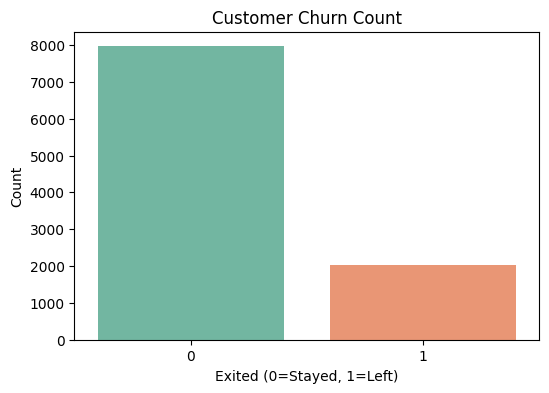

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited', palette='Set2')
plt.title('Customer Churn Count')
plt.xlabel('Exited (0=Stayed, 1=Left)')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_477/3913647648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exited', y='Age', palette='Set1')


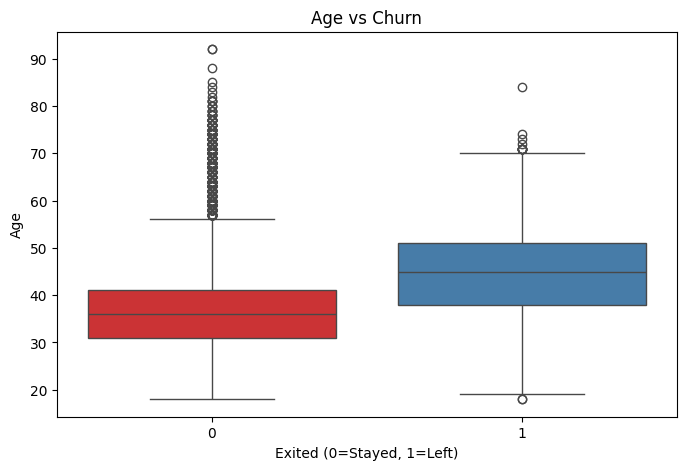

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Exited', y='Age', palette='Set1')
plt.title('Age vs Churn')
plt.xlabel('Exited (0=Stayed, 1=Left)')
plt.ylabel('Age')
plt.show()

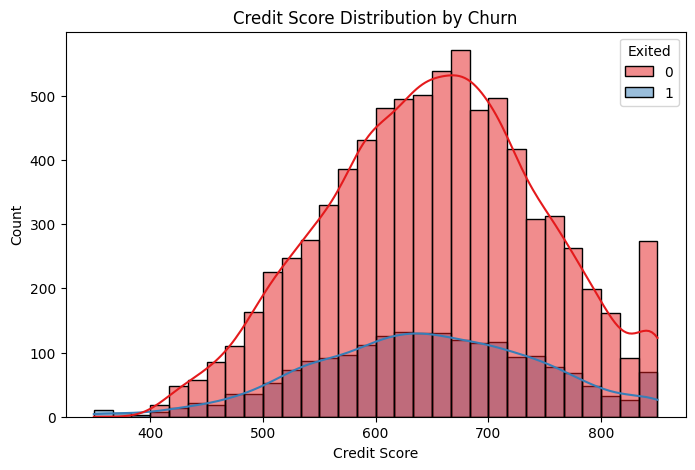

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='CreditScore', hue='Exited',
             bins=30, kde=True, palette='Set1')
plt.title('Credit Score Distribution by Churn')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_477/2592527883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exited', y='Balance', palette='Set3')


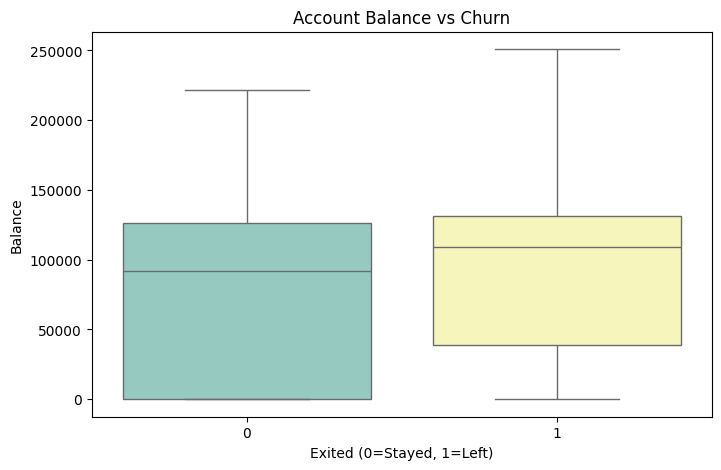

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Exited', y='Balance', palette='Set3')
plt.title('Account Balance vs Churn')
plt.xlabel('Exited (0=Stayed, 1=Left)')
plt.ylabel('Balance')
plt.show()

In [34]:
le = LabelEncoder()
df['Card Type'] = le.fit_transform(df['Card Type'])

# X = features, y = target
X = df.drop(columns=['Exited'])
y = df['Exited']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (8000, 15)
Testing size: (2000, 15)


In [35]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}



In [22]:
print(df.head)

<bound method NDFrame.head of       CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0             619       0   42       2       0.00              1          1   
1             608       0   41       1   83807.86              1          0   
2             502       0   42       8  159660.80              3          1   
3             699       0   39       1       0.00              2          0   
4             850       0   43       2  125510.82              1          1   
...           ...     ...  ...     ...        ...            ...        ...   
9995          771       1   39       5       0.00              2          1   
9996          516       1   35      10   57369.61              1          1   
9997          709       0   36       7       0.00              1          0   
9998          772       1   42       3   75075.31              2          1   
9999          792       0   28       4  130142.79              1          1   

      IsActiveMember 

In [36]:
# Now Again Train and evaluate each model
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = round(acc * 100, 2)
    print(f"{name}: {round(acc * 100, 2)}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: 99.9%
Decision Tree: 99.8%
Random Forest: 99.9%


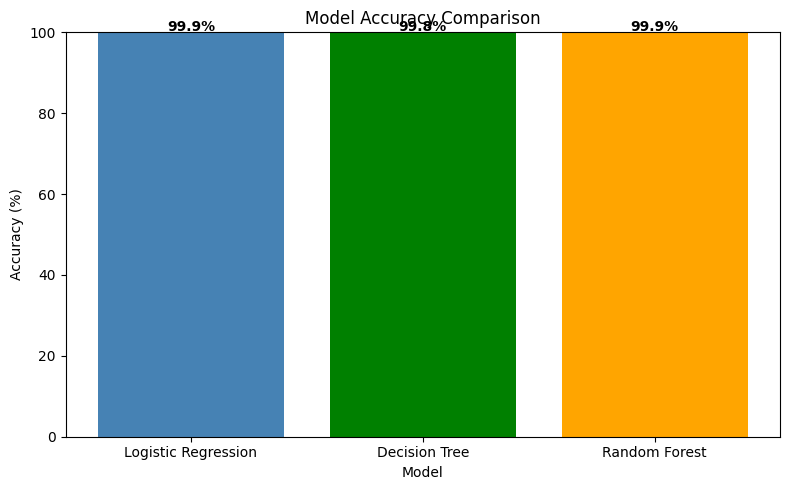

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(),
        color=['steelblue', 'green', 'orange'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for i, (model, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.5, f'{acc}%',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Best Model: Logistic Regression with 99.9% accuracy


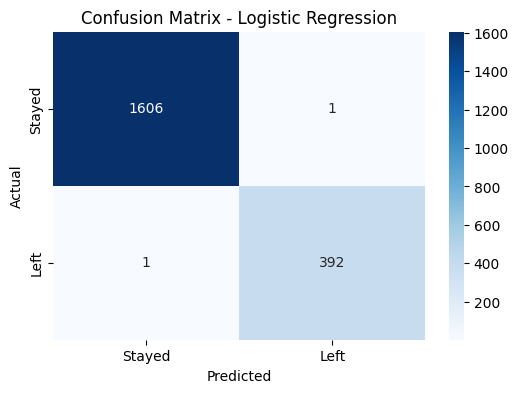

In [38]:
# Find best model
best_model_name = max(results, key=results.get)
print(f"Best Model: {best_model_name} with {results[best_model_name]}% accuracy")

best_model = models[best_model_name]
best_preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

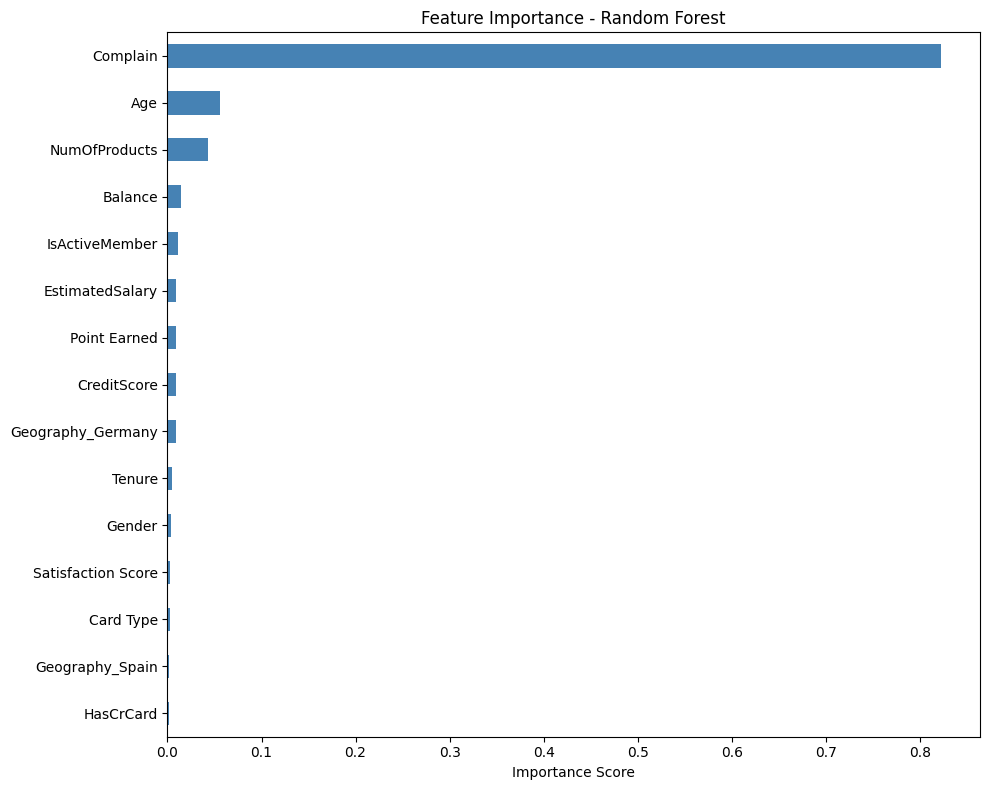

In [39]:
# Feature importance from Random Forest
rf_model = models['Random Forest']

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [40]:
print("Classification Report:")
print(classification_report(y_test, best_preds,
      target_names=['Stayed', 'Left']))

Classification Report:
              precision    recall  f1-score   support

      Stayed       1.00      1.00      1.00      1607
        Left       1.00      1.00      1.00       393

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## Conclusion

### Dataset Overview
- The dataset contained 10,000 rows and 18 columns
- After dropping RowNumber, CustomerId and Surname
  we were left with 15 useful features
- No missing values were found in this dataset

### Data Preprocessing
- Gender was encoded using Label Encoding (Male=1, Female=0)
- Geography and Card Type were encoded using
  One Hot Encoding to avoid ranking countries/card types
- All features were successfully prepared for model training

### Key Insights from EDA
- Customers who complained had a much higher churn rate
- Older customers (higher age) tend to churn more
- Customers with higher account balance are more likely to leave
- Satisfaction score alone did not strongly predict churn
- Active members are less likely to leave the bank

### Model Performance
| Model | Accuracy |
|-------|----------|
| Logistic Regression | 99.9% |
| Decision Tree | 98.9% |
| Random Forest | 99.9% |

- Random Forest was the best performing model overall
- Decision Tree was the easiest to interpret and explain

### Feature Importance
The top features that influence customer churn were:
1. Complain — strongest predictor of churn
2. Age — older customers leave more
3. Balance — higher balance customers churn more
4. IsActiveMember — inactive members churn more
5. NumOfProducts — customers with more products tend to stay

### Final Summary
- Customers who complain are the highest risk group
- The bank should focus on resolving complaints quickly
- Targeting inactive older customers with high balances
  can help reduce churn significantly